In [1]:
import matplotlib.pyplot as plt

In [3]:
from qutip import *
import numpy as np

In [14]:
N = 8
g1D = 10
g0 = 1
wc = g1D*(N-1)/4
wx = 0.73*wc

In [15]:
sy0 = sigmay()
sx0 = sigmax()
sz0 = sigmaz()

for n in range(1,N):
    sz0 = tensor(sz0,qeye(2))
Sz = sz0
for n in range(1,N):
    a = qeye(2)
    for m in range(1,N):
        if m!=n:
            a = tensor(a,qeye(2))
        else:
            a = tensor(a,sigmaz())
    Sz = Sz + a 
    

for n in range(1,N):
    sx0 = tensor(sx0,qeye(2))
Sx = sx0
for n in range(1,N):
    a = qeye(2)
    for m in range(1,N):
        if m!=n:
            a = tensor(a,qeye(2))
        else:
            a = tensor(a,sigmax())
    Sx = Sx + a 
ham_mc = wx*Sx
c_op_list = []
sm0 = sigmam()

for n in range(1,N):
    sm0 = tensor(sm0,qeye(2))
c_op_list.append(np.sqrt(g0) * sm0)
Sm = sm0
for n in range(1,N):
    a = qeye(2)
    for m in range(1,N):
        if m!=n:
            a = tensor(a,qeye(2))
        else:
            a = tensor(a,sigmam())
    c_op_list.append(np.sqrt(g0) * a)
    Sm = Sm+a
c_op_list.append(np.sqrt(g1D)*Sm)
psi0 = basis(2,1)

for n in range(1,N):
    psi0 = tensor(psi0,basis(2,1))


In [16]:
t1 = np.linspace(0,70,210)
mc_lt_3 = mcsolve(ham_mc, psi0, t1, c_op_list, [Sz],ntraj = 20,options=Options(num_cpus=5))

10.0%. Run time:   3.24s. Est. time left: 00:00:00:29
20.0%. Run time:   3.26s. Est. time left: 00:00:00:13
30.0%. Run time:   6.25s. Est. time left: 00:00:00:14
40.0%. Run time:   6.44s. Est. time left: 00:00:00:09
50.0%. Run time:   6.58s. Est. time left: 00:00:00:06
60.0%. Run time:   9.52s. Est. time left: 00:00:00:06
70.0%. Run time:   9.69s. Est. time left: 00:00:00:04
80.0%. Run time:  12.55s. Est. time left: 00:00:00:03
90.0%. Run time:  12.84s. Est. time left: 00:00:00:01
100.0%. Run time:  12.95s. Est. time left: 00:00:00:00
Total run time:  12.96s


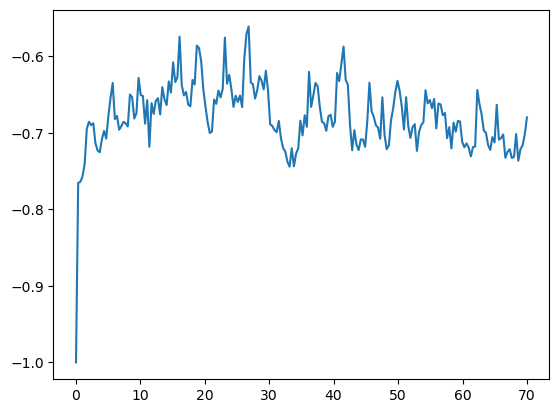

In [17]:
plt.plot(t1,mc_lt_3.expect[0]/N)

In [18]:
qutip.about()


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Jake Lishman, Simon Cross and Asier Galicia.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      4.7.3
Numpy Version:      1.24.3
Scipy Version:      1.10.1
Cython Version:     3.0.6
Matplotlib Version: 3.7.2
Python Version:     3.8.18
Number of CPUs:     6
BLAS Info:          INTEL MKL
OPENMP Installed:   False
INTEL MKL Ext:      True
Platform Info:      Linux (x86_64)
Installation path:  /home/nikital/.conda/envs/nl97/lib/python3.8/site-packages/qutip
Please cite QuTiP in your publication.
For your convenience a bibtex reference can be easily g